<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_8_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

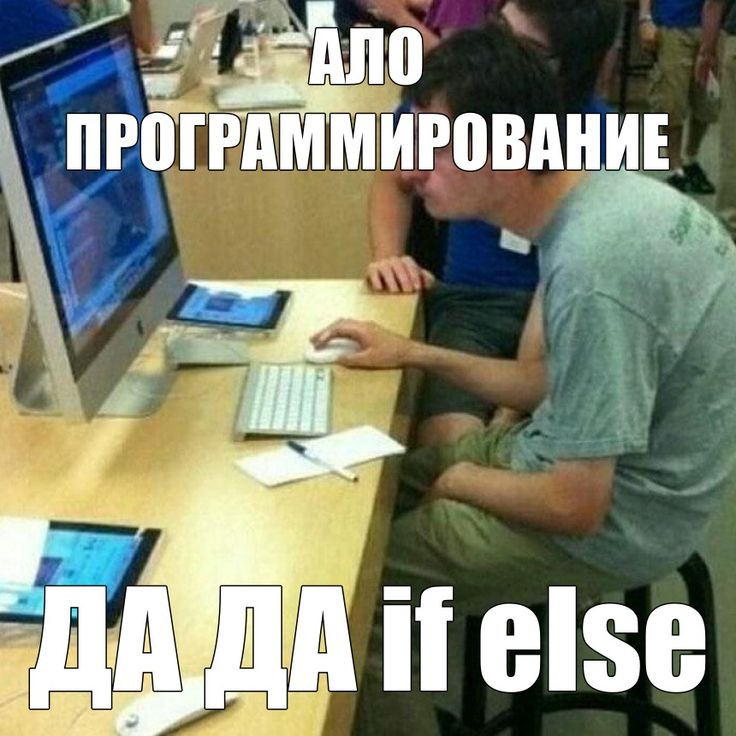

# Префиксное дерево
Префиксное дерево или бор (англ. trie) — структура данных для компактного хранения строк, устроенная в виде дерева, где на рёбрах между вершинами записаны символы, а некоторые вершины помечены терминальными.

Говорят, что префиксное дерево принимает строку $s$, если существует такая терминальная вершина $v$, что, если выписать подряд все буквы на путях от корня до $v$, то получится строка $s$.

Бор сам по себе можно использовать для разных задач:

* Хранение строк: если есть много повторяющихся длинных префиксов, то бор может занимать гораздо меньше места, чем массив или set строк.
* Сортировка строк: по построенному бору можно пройтись dfs-ом и вывести все строки в лексикографическом порядке.
* Просто как множество строк: как мы увидим, в бор легко добавлять и удалять слова, а также делать проверки вхождения.

С точки зрения теории автоматов, каждая вершина — это состояние, а все корректные односимвольные дополнения являются корректными переходами в автомате. Бор таким образом является автоматом, проверяющим вхождение слова в множество.

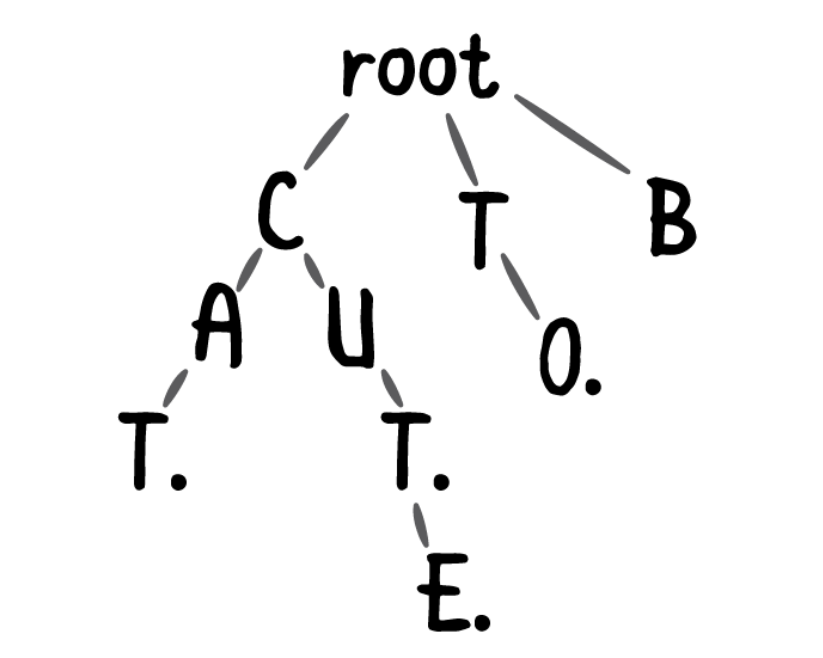

In [1]:
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end = False


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word: str) -> None:
        node = self.root
        for char in word:
            node = node.children.setdefault(char, TrieNode())
        node.is_end = True

    def search(self, word: str) -> bool:
        node = self._find_node(word)
        return node is not None and node.is_end

    def starts_with(self, prefix: str) -> bool:
        return self._find_node(prefix) is not None

    def delete(self, word: str) -> bool:
        """Удаляет слово. Возвращает True, если слово было удалено."""
        return self._delete(self.root, word, 0)

    def _delete(self, node, word, depth):
        if node is None:
            return False

        # дошли до конца слова
        if depth == len(word):
            if not node.is_end:
                return False  # слова не было
            node.is_end = False
            return len(node.children) == 0  # можно ли удалить узел

        char = word[depth]
        if char not in node.children:
            return False

        should_delete_child = self._delete(node.children[char], word, depth + 1)

        if should_delete_child:
            del node.children[char]
            return not node.is_end and len(node.children) == 0

        return False

    def words_with_prefix(self, prefix: str):
        """Возвращает все слова с данным префиксом."""
        node = self._find_node(prefix)
        if node is None:
            return []

        result = []
        self._dfs(node, prefix, result)
        return result

    def _dfs(self, node, path, result):
        if node.is_end:
            result.append(path)

        for char, next_node in node.children.items():
            self._dfs(next_node, path + char, result)

    def _find_node(self, prefix: str):
        node = self.root
        for char in prefix:
            if char not in node.children:
                return None
            node = node.children[char]
        return node


# Пример использования
trie = Trie()
words = ["cat", "car", "care", "dog", "door"]
for w in words:
    trie.insert(w)

print(trie.words_with_prefix("ca"))   # ['cat', 'car', 'care']

trie.delete("car")
print(trie.words_with_prefix("ca"))   # ['cat', 'care']

print(trie.search("car"))  # False
print(trie.search("care")) # True

['cat', 'car', 'care']
['cat', 'care']
False
True


# Алгоритм Ахо-Корасик
Представим, что мы работаем журналистами в некотором авторитарном государстве, контролирующем СМИ, и в котором время от времени издаются законы, запрещающие упоминать определенные политические события или использовать определенные слова. Как эффективно реализовать подобную цензуру программно?

Более формально, пусть дан набор строк $s_1,s_2,…,s_m$ алфавита размера $k$ суммарной длины $n$, называемый словарем, и длинный текст $t$. Необходимо определить, есть ли в тексте хотя бы одно слово из словаря, и если есть, то на какой позиции.

Мы уже умеем решать это, например, за $O(n⋅∣t∣)$ независимо проверяя каждое слово на вхождение, или за $O(max∣s_i ∣⋅∣t∣)$ хешируя все короткие подстроки. Но мы всё же хотим масштабируемое решение за $O(∣t∣)$, и сегодня мы построим автомат, который решит нашу задачу.

Алгоритм Ахо-Корасик (названный по фамилиям создателей, Альфреда Ахо и Маргарет Корасик; в народе — «карасик») за $O(nk)$ времени и памяти строит префиксное дерево для этого набора строк, а затем по этому дереву строит автомат, который может использоваться в этой и многих других строковых задачах. Алгоритм был открыт в 1975-м году, и с тех пор получил широкое распространение в системных программах для потоковой обработки текстов — например, в утилите grep.


Построим по словарю префиксное дерево. Предположим, что строки из словаря не являются подстроками друг друга — в этом случае большие можно выкинуть, но позже мы увидим, что это требование избыточно.

Для решения задачи мы построим автомат, в котором после считывания каждого очередного символа будет поддерживаться состояние, соответствующее наибольшей строке, являющейся одновременно

* префиксом какой-то строки из словаря, и
* суффиксом считанного на данный момент текста.

Этой информации о состоянии нам достаточно: если это состояние помечено терминальным, то суффикс совпадает с какой-то строкой из словаря, и мы выводим его. Иначе по определению мы нашли самый длинный принимаемый бором суффикс, но никакая его подстрока не является запрещенной, а значит в этой позиции никакое запрещенное слово не содержится.

Сложная часть — построить такой автомат, то есть по состоянию в префиксном дереве и новому символу быстро находить вершину, соответствующую наидлиннейшему входящему в бор суффиксу нового выписанного префикса текста. Для этого нам понадобятся несколько вспомогательных понятий.

1. Trie (префиксное дерево)

Хранит все шаблоны.

2. Fail links (суффиксные ссылки)

Позволяют быстро “откатываться”, если символ не подошёл.

**Определение**. Суффиксная ссылка $l(v)$ ведёт в вершину $u≠v$, которая соответствует наидлиннейшему принимаемому бором суффиксу $v$.

3. Output list

Хранит шаблоны, заканчивающиеся в узле.

### Часть 1: Построение Trie


In [2]:
def _build_trie(self, patterns):
    for pattern in patterns:
        node = self.root
        for char in pattern:
            node = node.children.setdefault(char, Node())
        node.output.append(pattern)

Добавляем каждое слово в дерево посимвольно.

Для:
```python
["he", "she", "his"]
```
получим:
```python
root
 ├── h
 │   ├── e   ("he")
 │   └── i
 │       └── s ("his")
 └── s
     └── h
         └── e ("she")
```
output.append(pattern)

Когда слово заканчивается — отмечаем это:
```
node.output.append(pattern)
```
Например:
узел e в she хранит:
```
["she"]
```

### Часть 2: Fail Links
Что такое fail link?

Если не можем идти дальше по Trie —
прыгаем в максимально длинный возможный суффикс.
```
def _build_fail_links(self):
Сначала:
for child in self.root.children.values():
    child.fail = self.root
```

Все дети корня ссылаются в root.

Потом BFS:
```
while queue:
    current = queue.popleft()
```
Обходим дерево по уровням.
```
Для каждого ребенка:
for char, child in current.children.items():
Ищем fail:
fail_node = current.fail

while fail_node and char not in fail_node.children:
    fail_node = fail_node.fail
```
Смысл:

Ищем ближайший узел,
где есть переход по тому же символу.

Пример:
```
Если стоим в:

she
```
и fail нужен для e,
ищем похожий путь через суффиксы.

Назначаем fail:
```python
child.fail = fail_node.children[char] if fail_node and char in fail_node.children else self.root
```


### Часть 3: Наследование output
Очень важная строка:
```
child.output += child.fail.output
```
Почему?

Если нашли "hers",
можем одновременно найти "he".

Пример:
```
hers
```
может содержать окончания других шаблонов.



### Часть 4: Поиск по тексту
```python
def search(self, text):
#Начинаем с root:
node = self.root
#Идём по тексту:
for i, char in enumerate(text):
#Если перехода нет:
while node and char not in node.children:
    node = node.fail

#Прыгаем по fail links.

#Если переход есть:
node = node.children[char] if node and char in node.children else self.root
#Если нашли слово:
for pattern in node.output:
    results.append((i - len(pattern) + 1, pattern))
```
Пошаговый пример

Текст:
```
ushers
```
Читаем u

Нет перехода → root

Читаем s

Идем в s

Читаем h

Идем в sh

Читаем e

Идем в she

Нашли:
```
she
```
и через fail ещё:
```
he
```
Читаем r

Переход

Читаем s

Находим:
```
hers
```

In [3]:
from collections import deque


class Node:
    def __init__(self):
        self.children = {}
        self.fail = None
        self.output = []  # список шаблонов, которые заканчиваются в этом узле


class AhoCorasick:
    def __init__(self, patterns):
        self.root = Node()
        self._build_trie(patterns)
        self._build_fail_links()

    def _build_trie(self, patterns):
        for pattern in patterns:
            node = self.root
            for char in pattern:
                node = node.children.setdefault(char, Node())
            node.output.append(pattern)

    def _build_fail_links(self):
        queue = deque()

        # 1. Для детей корня fail = root
        for child in self.root.children.values():
            child.fail = self.root
            queue.append(child)

        # 2. BFS
        while queue:
            current = queue.popleft()

            for char, child in current.children.items():
                fail_node = current.fail

                while fail_node and char not in fail_node.children:
                    fail_node = fail_node.fail

                child.fail = fail_node.children[char] if fail_node and char in fail_node.children else self.root
                child.output += child.fail.output

                queue.append(child)

    def search(self, text):
        node = self.root
        results = []

        for i, char in enumerate(text):
            while node and char not in node.children:
                node = node.fail

            node = node.children[char] if node and char in node.children else self.root

            for pattern in node.output:
                results.append((i - len(pattern) + 1, pattern))

        return results

In [4]:
patterns = ["he", "she", "his", "hers"]
text = "ushers"

ac = AhoCorasick(patterns)
matches = ac.search("ushers")
print(matches)

[(1, 'she'), (2, 'he'), (2, 'hers')]


Пошаговая анимация построения Trie
```python
root
 ├── h
 │    ├── e [he]
 │    │    └── r
 │    │         └── s [hers]
 │    └── i
 │         └── s [his]
 └── s
      └── h
           └── e [she]
```
Строим fail-ссылки

Для узла sh

Путь:
```
s → h
```
```
fail(sh) = h
```
Почему?

Потому что:
если убрать s,
остаётся h,
а такой путь есть.

Для узла she
```
fail(she) = he
```
Получаем:
```python
root
 ├── h
 │    ├── e [he]
 │    │    └── r
 │    │         └── s [hers]
 │    └── i
 │         └── s [his]
 └── s
      └── h --fail--> h
           └── e [she] --fail--> e(he)
```
Пошаговый поиск в "ushers"

```python
u s h e r s
0 1 2 3 4 5
```
Символ u

Нет перехода → root

Символ s

Идём в s

Символ h

Идём в sh

Символ e

Идём в she

Найдено:
```
she
```
Через fail:
```
she → fail → he
```
Находим ещё:
```
he
```
Символ r

Переходим дальше

Символ s

Находим:
```
hers
```
Финальный результат:
```python
[(1, 'she'), (2, 'he'), (2, 'hers')]
```

**Сложность**  
Построение:
$O(sum(len(patterns)))$  
Поиск:
$O(len(text) + matches)$

# Дерево палиндромов

Дерево палиндромов (англ. palindromic tree, EERTREE) — структура данных, использующая другой, более мощный формат хранения информации обо всех подпалиндромах, чем размеры $n$ палиндромов. Она была предложена Михаилом Рубинчиком на летних петрозаводских сборах в 2014-м году.

**Лемма.** В строке есть не более $n$ различных подпалиндромов.

Этот факт позволяет сопоставить всем палиндромам строки сопоставить следующую структуру: возьмём от каждого палиндрома его правую половину (например, $caba$ для $abacaba$ или $ba$ для $abba$; будем рассматривать пока что только чётные палиндромы) и добавим все эти половины в префиксное дерево — получившуюся структуру и будем называть деревом палиндромов.

Наивный алгоритм построения будет в худшем случае работать за $O(n^2)$, но это можно делать и более эффективно.

Будем поддерживать наибольший суффикс-палиндром. Когда мы будем дописывать очередной символ $c$, нужно найти наибольший суффикс этого палиндрома, который может быть дополнен символом $c$ — это и будет новый наидлиннейший суффикс-палиндром.

Для этого поступим аналогично алгоритму Ахо-Корасик: будем поддерживать для каждого палиндрома суффиксную ссылку $l(v)$, ведущую из $v$ в её наибольший суффикс-палиндром. При добавлении очередного символа, будем подниматься по суффиксным ссылкам, пока не найдём вершину, из которой можно совершить нужный переход.

Если в подходящей вершине этого перехода не существовало, то нужно создать новую вершину, и для неё тоже понадобится своя суффиксная ссылка. Чтобы найти её, будем продолжать подниматься по суффиксным ссылкам предыдущего суффикс-палиндрома, пока не найдём второе такое место, которое мы можем дополнить символом $c$.

In [5]:
class EertreeNode:
    def __init__(self, length):
        self.length = length
        self.link = 0
        self.next = {}
        self.occurrences = 0


class Eertree:
    def __init__(self):
        self.nodes = []

        # root -1: воображаемый палиндром длины -1
        self.nodes.append(EertreeNode(-1))

        # root 0: пустой палиндром
        self.nodes.append(EertreeNode(0))

        self.nodes[0].link = 0
        self.nodes[1].link = 0

        self.s = []
        self.last = 1
        self.size = 2

    def add_char(self, ch):
        self.s.append(ch)
        pos = len(self.s) - 1
        curr = self.last

        # Шаг 1: ищем максимальный суффикс-палиндром
        while True:
            curlen = self.nodes[curr].length
            if pos - 1 - curlen >= 0 and self.s[pos - 1 - curlen] == ch:
                break
            curr = self.nodes[curr].link

        # Шаг 2: если переход уже есть — просто увеличиваем счётчик
        if ch in self.nodes[curr].next:
            self.last = self.nodes[curr].next[ch]
            self.nodes[self.last].occurrences += 1
            return

        # Шаг 3: создаём новый узел
        new_node = EertreeNode(self.nodes[curr].length + 2)
        self.nodes.append(new_node)
        self.size += 1

        new_index = self.size - 1
        self.nodes[curr].next[ch] = new_index

        # Шаг 4: строим suffix link
        if new_node.length == 1:
            new_node.link = 1
        else:
            temp = self.nodes[curr].link
            while True:
                templen = self.nodes[temp].length
                if pos - 1 - templen >= 0 and self.s[pos - 1 - templen] == ch:
                    break
                temp = self.nodes[temp].link

            new_node.link = self.nodes[temp].next[ch]

        new_node.occurrences = 1
        self.last = new_index

    def build(self, string):
        for ch in string:
            self.add_char(ch)

    def get_all_palindromes(self):
        result = []
        for i in range(2, self.size):
            result.append(self._restore_palindrome(i))
        return result

    def _restore_palindrome(self, index):
        length = self.nodes[index].length
        palindrome = []

        # Восстанавливаем из строки
        for i in range(len(self.s)):
            candidate = ''.join(self.s[i:i+length])
            if candidate == candidate[::-1]:
                if self._exists(index, candidate):
                    return candidate
        return ""

    def _exists(self, index, candidate):
        return len(candidate) == self.nodes[index].length

In [6]:
tree = Eertree()
tree.build("ababa")

print(tree.get_all_palindromes())

['a', 'a', 'aba', 'aba', 'ababa']


Для каждого символа:

Мы:
1. ищем suffix palindrome,
2. максимум один раз создаём новый узел,
3. suffix links позволяют быстро откатываться.

Каждый переход проходит ограниченное число раз.

Каждый узел хранит:
```python
length       # длина палиндрома
link         # suffix link
next         # переходы
occurrences  # сколько раз встретился
```

Два специальных корня

root -1

Для нечётных палиндромов:
```python
length = -1
```
root 0

Для чётных:
```python
length = 0
```
Пример дерева для "ababa"
```python
(-1)
 |
(0)
 | \
 a  b
 |   |
aba bab
 |
ababa
```

# Суффиксный массив
Суффиксный массив, автомат и дерево обобщённо называют суффиксными структурами данных. Они применяются в множестве различных задач, встречающихся как на олимпиадах, так и на практике.

Суффиксные структуры часто (но не всегда) взаимозаменяемые, и более того, конвертируются друг в друга за линейное время. Суффиксный массив — самый простой из них, поэтому мы с него и начнём.

**Суффиксным массивом** (англ. suffix array, суфмасс) строки
$s$ называется перестановка индексов начал её суффиксов, которая задаёт порядок их лексикографической сортировки. Иными словами, чтобы его построить, нужно выполнить сортировку всех суффиксов заданной строки.

Сортировка всех суффиксов строки «mississippi$»




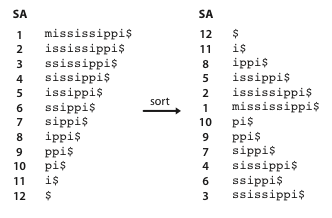

Где это может быть полезно. Пусть вы хотите основать ещё один поисковик, и чтобы получить финансирование, вам нужно сделать хоть что-то минимально работающее — хотя бы просто научиться искать по ключевому слову документы, включающие его, а также позиции их вхождения (в 90-е это был бы уже довольно сильный MVP). Простыми алгоритмами — полиномиальными хешами, z- и префикс-функцией и даже Ахо-Корасиком — это сделать быстро нельзя, потому что на каждый раз нужно проходиться по всем данным, а суффиксными структурами — можно.

В случае с суффиксным массивом можно сделать следующее: сконкатенировать все строки-документы с каким-нибудь внеалфавитным разделителем ($), построить по ним суффиксный массив, а дальше для каждого запроса искать бинарным поиском первый суффикс в суффиксном массиве, который меньше искомого слова, а также последний, который меньше. Все суффиксы между этими двумя будут включать искомую строку как префикс.

Например, строка iss в суффиксном массиве из примера найти будет зажата между суффиксами issippi$ и ississippi$, которые имеют индексы 2 и 5, а значит ровно на этих позициях и будет входить в исходный текст.

Работать такой алгоритм будет за $O(∣t∣log∣s∣)$, и позже это можно будет оптимизировать до $O(∣t∣+log∣s∣)$, что является одним из самых оптимальных алгоритмов поиска.

Теперь научимся его строить.



## Простая реализация $O(n log^2 n)$


In [7]:
def build_suffix_array(s):
    n = len(s)
    suffixes = []

    for i in range(n):
        suffixes.append((s[i:], i))

    suffixes.sort()

    return [idx for (_, idx) in suffixes]



In [8]:
s = "banana"
sa = build_suffix_array(s)
print(sa)

[5, 3, 1, 0, 4, 2]


```python
s = "banana"
```
Все её суффиксы:
```python
0 banana
1 anana
2 nana
3 ana
4 na
5 a
```
Сортируем лексикографически:
```python
5 a
3 ana
1 anana
0 banana
4 na
2 nana
```
Суффиксный массив:

Храним только индексы:
```python
[5, 3, 1, 0, 4, 2]
```

## Prefix Doubling

Строит за: $O(n log n)$

Для удобства допишем в конец строки какой-нибудь символ, который лексикографически меньше любого другого. Для стандартной ASCII обычно выбирают либо «$», либо «#».

длине 1 ($2^0$)

потом:

длине 2 ($2^1$)

потом:

длине 4 ($2^2$)

потом:

длине 8 ($2^3$)

...

In [9]:
def suffix_array(s):
    s += "$"
    n = len(s)
    p = [0] * n
    c = [0] * n

    # k = 0
    a = sorted((ch, i) for i, ch in enumerate(s))
    for i in range(n):
        p[i] = a[i][1]

    c[p[0]] = 0
    for i in range(1, n):
        c[p[i]] = c[p[i - 1]] + (a[i][0] != a[i - 1][0])

    k = 0
    while (1 << k) < n:
        p = [(x - (1 << k)) % n for x in p]
        p.sort(key=lambda x: (c[x], c[(x + (1 << k)) % n]))

        c_new = [0] * n
        c_new[p[0]] = 0

        for i in range(1, n):
            prev = (c[p[i - 1]], c[(p[i - 1] + (1 << k)) % n])
            now = (c[p[i]], c[(p[i] + (1 << k)) % n])
            c_new[p[i]] = c_new[p[i - 1]] + (now != prev)

        c = c_new
        k += 1

    return p[1:]  # без $

In [10]:
print(suffix_array("banana"))

[5, 3, 1, 0, 4, 2]


# Наибольшие общие префиксы

Для многих применений часто бывает полезным возможность находить длину **наибольшего общего префикса**(англ. largest common prefix) для различных суффиксов строки.

Например, чтобы просто сравнить две подстроки, мы можем найти наибольший префикс соответствующих суффиксов и посмотреть на следующий символ — так же, как это обычно делается хешами.

Утверждение. Пусть мы знаем $lcp$ для всех суффиксов, которые являются соседями в суффиксном массиве — это будет какой-то массив длины $(n−1)$. Тогда общий префикс для $i$-того и $j$-того суффикса будет равен минимуму между $c_i$-тым и $c_j$ -тым элементом в массиве lcp (напомним, что $c_i$
  — класс эквивалентности — это номер $i$-того суффикса в суффиксном массиве).
  



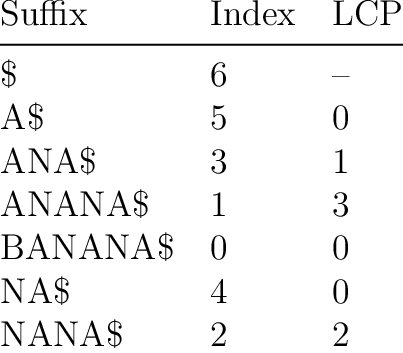